# Download the dependencies

In [ ]:
# Optional: store the hugging face read only key to HF_TOKEN

!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn datasets

%pip install kagglehub

#Transform images into the same format and size

In [2]:
# =============================================================================
#  Image Normalization — Animals-10 Dataset
#  · Converts to RGB
#  · Resizes to TARGET_SIZE
#  · Saves organized by class in subfolders
# =============================================================================
!pip install -q datasets pillow tqdm

import io
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from datasets import load_dataset
from PIL import Image

# ── Config ────────────────────────────────────────────────────────────────────
TARGET_SIZE  = (90, 90)
DATA_DIR     = Path("/content/animals10/normalized-224")
JPEG_QUALITY = 92
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Loading dataset...")
ds = load_dataset("34data/animal-10", split="train")
print(f"  → {len(ds):,} examples\n")

counters  = defaultdict(int)
failed    = 0

for sample in tqdm(ds, desc="Normalizing", unit="img"):
    try:
        # ✅ bytes → PIL.Image
        img = Image.open(io.BytesIO(sample["image"])).convert("RGB")
        img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

        # Clase: "v12/Real/.../cane/imagen.jpg" → "cane"
        parts = sample["filename"].replace("\\", "/").split("/")
        cls   = parts[-2] if len(parts) >= 2 else "unknown"
        if cls == "unknown":
            raise ValueError(f"Bad filename: {sample['filename']}")

        out_path = DATA_DIR / cls / f"{counters[cls]:06d}.jpg"
        out_path.parent.mkdir(exist_ok=True)
        img.save(out_path, format="JPEG", quality=JPEG_QUALITY)
        counters[cls] += 1

    except Exception as e:
        failed += 1

# ── Reporte ───────────────────────────────────────────────────────────────────
total = sum(counters.values())
print(f"\n{'═'*50}")
print(f"Saved  : {total:,}  |  Failed : {failed:,}")
print(f"\nClass distribution:")
for cls, n in sorted(counters.items(), key=lambda x: -x[1]):
    print(f"  {cls:<20} {n:>6,} images")

print("\nVerification (size + mode):")
for cls in sorted(counters):
    first = next((DATA_DIR / cls).glob("*.jpg"))
    with Image.open(first) as im:
        print(f"  {cls:<20} {im.size}  mode={im.mode}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

animal-10_0007.parquet:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

animal-10_0003.parquet:   0%|          | 0.00/12.5M [00:00<?, ?B/s]

...

animal-10_0027.parquet:   0%|          | 0.00/2.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26177 [00:00<?, ? examples/s]

  → 26,177 examples



Normalizing:   0%|          | 0/26177 [00:00<?, ?img/s]


══════════════════════════════════════════════════
Saved  : 26,177  |  Failed : 0

Class distribution:
  cane                  4,863 images
  ragno                 4,821 images
  gallina               3,098 images
  cavallo               2,623 images
  farfalla              2,112 images
  mucca                 1,865 images
  scoiattolo            1,861 images
  pecora                1,820 images
  gatto                 1,668 images
  elefante              1,446 images

Verification (size + mode):
  cane                 (90, 90)  mode=RGB
  cavallo              (90, 90)  mode=RGB
  elefante             (90, 90)  mode=RGB
  farfalla             (90, 90)  mode=RGB
  gallina              (90, 90)  mode=RGB
  gatto                (90, 90)  mode=RGB
  mucca                (90, 90)  mode=RGB
  pecora               (90, 90)  mode=RGB
  ragno                (90, 90)  mode=RGB
  scoiattolo           (90, 90)  mode=RGB


#Verifing images have same format and size

In [3]:
from pathlib import Path
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

DATA_DIR = Path("/content/animals10/normalized-224")

sizes   = Counter()
modes   = Counter()
formats = Counter()
errors  = 0

all_images = list(DATA_DIR.rglob("*.jpg"))
print(f"Total images found: {len(all_images):,}\n")

for path in tqdm(all_images, desc="Checking", unit="img"):
    try:
        with Image.open(path) as im:
            sizes[im.size]     += 1
            modes[im.mode]     += 1
            formats[im.format] += 1
    except Exception:
        errors += 1

print(f"\n{'═'*40}")
print(f"Unique sizes   : {dict(sizes)}")
print(f"Unique modes   : {dict(modes)}")
print(f"Unique formats : {dict(formats)}")
print(f"Corrupt files  : {errors}")

# Pass/fail summary
ok = len(sizes) == 1 and sizes.get((224, 224)) and len(modes) == 1 and modes.get("RGB")
print(f"\n{'✅ All images are uniform!' if ok else '❌ Inconsistencies found — check counters above'}")

Total images found: 26,177



Checking:   0%|          | 0/26177 [00:00<?, ?img/s]


════════════════════════════════════════
Unique sizes   : {(90, 90): 26177}
Unique modes   : {'RGB': 26177}
Unique formats : {'JPEG': 26177}
Corrupt files  : 0

❌ Inconsistencies found — check counters above


# EDA (Visualizations)



Directory:           /content/animals10/normalized-224
Total images found:  26,177


Analyzing sample:   0%|          | 0/2000 [00:00<?, ?img/s]


══════════════════════════════════════════════════════════════════════
        ANIMALS-10 DATASET — IMAGE STATISTICS (local folder)
══════════════════════════════════════════════════════════════════════
  Total images in folder     : 26,177
  Images analyzed            : 2,000  (skipped 0)

  Width  — min:   90  max:   90  mean: 90  median: 90
  Height — min:   90  max:   90  mean: 90  median: 90

  Channel means (R, G, B)    : [133.46 128.31 106.62]
  Channel stds  (R, G, B)    : [53.02 53.08 53.9 ]

──────────────────────────────────────────────────────────────────────
  CLASS DISTRIBUTION
──────────────────────────────────────────────────────────────────────
  cane           (dog         )  4,863  ███████████████████████████████████  (18.6%)
  cavallo        (horse       )  2,623  ██████████████████  (10.0%)
  elefante       (elephant    )  1,446  ██████████  ( 5.5%)
  farfalla       (butterfly   )  2,112  ███████████████  ( 8.1%)
  gallina        (chicken     )  3,098  ███████████

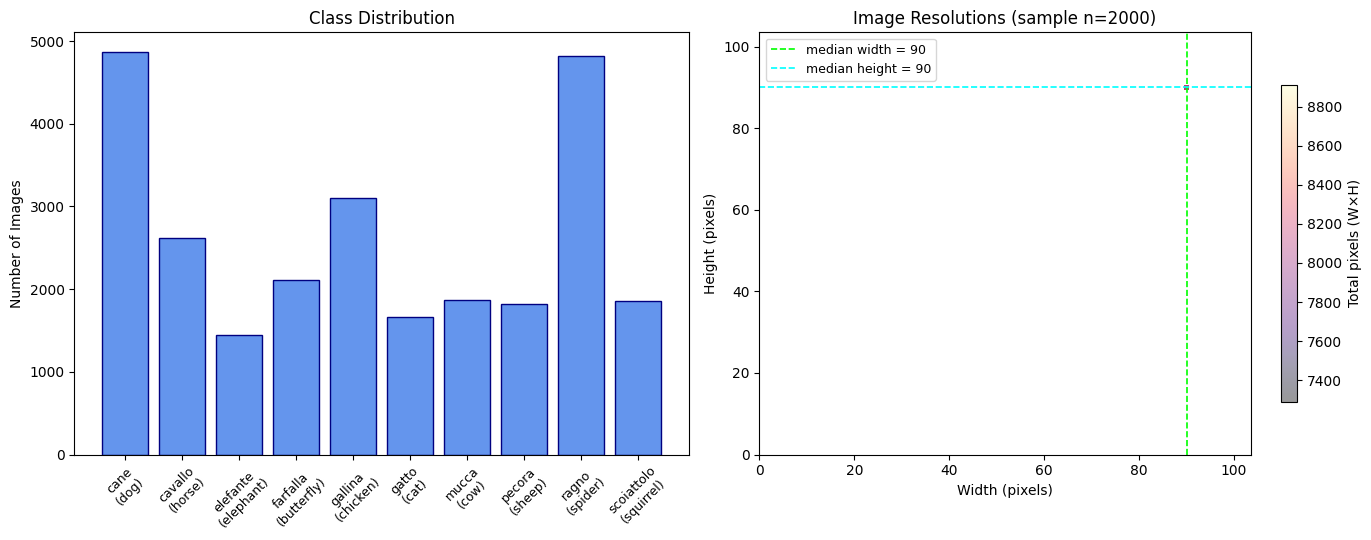

In [4]:
from pathlib import Path
import numpy as np
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ────────────────────────────────────────────────────────────────
DATA_DIR = Path("/content/animals10/normalized-224")
# ────────────────────────────────────────────────────────────────

# Class name translation (Italian → English)
translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "ragno": "spider",
    "scoiattolo": "squirrel"
}

# ── Collect all images and extract class names ───────────────────────────────
all_images = list(DATA_DIR.glob("*/*.jpg"))   # use .rglob if needed for deeper nesting

print(f"Directory:           {DATA_DIR}")
print(f"Total images found:  {len(all_images):,}")

if len(all_images) == 0:
    print("No .jpg images found → please check the path")
    # You can add: raise FileNotFoundError(...) or sys.exit() if preferred

# Extract class from parent folder name
def get_class(path: Path) -> str:
    return path.parent.name

all_classes = [get_class(p) for p in all_images]
class_counts = Counter(all_classes)
N_total = len(all_classes)

# ── Sample images for resolution & pixel statistics (fast) ───────────────────
EDA_SAMPLE = 2000
rng = np.random.default_rng(42)
sample_paths = rng.choice(all_images, size=min(EDA_SAMPLE, N_total), replace=False)

widths = []
heights = []
mean_pixels = []
std_pixels = []
skipped = 0

for path in tqdm(sample_paths, desc="Analyzing sample", unit="img"):
    try:
        with Image.open(path) as img:
            img = img.convert('RGB')
            arr = np.asarray(img, dtype=np.float32)

            h, w = arr.shape[:2]
            heights.append(h)
            widths.append(w)

            mean_pixels.append(arr.mean(axis=(0,1)))
            std_pixels.append(arr.std(axis=(0,1)))
    except Exception:
        skipped += 1

widths = np.array(widths)
heights = np.array(heights)
mean_pixels = np.stack(mean_pixels) if mean_pixels else np.array([])
std_pixels  = np.stack(std_pixels)  if std_pixels  else np.array([])

n_valid = len(widths)

print("\n" + "═"*70)
print("        ANIMALS-10 DATASET — IMAGE STATISTICS (local folder)")
print("═"*70)
print(f"  Total images in folder     : {N_total:,}")
print(f"  Images analyzed            : {n_valid:,}  (skipped {skipped})")

if n_valid > 0:
    print(f"\n  Width  — min: {widths.min():4d}  max: {widths.max():4d}  "
          f"mean: {widths.mean():.0f}  median: {np.median(widths):.0f}")
    print(f"  Height — min: {heights.min():4d}  max: {heights.max():4d}  "
          f"mean: {heights.mean():.0f}  median: {np.median(heights):.0f}")

    global_mean = mean_pixels.mean(axis=0)
    global_std  = std_pixels.mean(axis=0)
    print(f"\n  Channel means (R, G, B)    : {global_mean.round(2)}")
    print(f"  Channel stds  (R, G, B)    : {global_std.round(2)}")

# ── Class distribution ───────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("  CLASS DISTRIBUTION")
print(f"{'─'*70}")
max_count = max(class_counts.values(), default=1)

for cls, count in sorted(class_counts.items()):
    eng = translate.get(cls, cls)
    bar = "█" * int((count / max_count) * 35)
    print(f"  {cls:<14} ({eng:<12}) {count:>6,}  {bar}  ({count/N_total:5.1%})")

# ── Plots ────────────────────────────────────────────────────────────────────
if n_valid > 10:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Plot 1: Class distribution
    labels_sorted = sorted(class_counts.keys())
    counts_sorted = [class_counts[c] for c in labels_sorted]
    eng_labels = [f"{c}\n({translate.get(c, c)})" for c in labels_sorted]

    axes[0].bar(eng_labels, counts_sorted, color="cornflowerblue", edgecolor="navy")
    axes[0].set_title("Class Distribution")
    axes[0].set_ylabel("Number of Images")
    axes[0].tick_params(axis='x', rotation=45, labelsize=9)

    # Plot 2: Resolution scatter
    scatter = axes[1].scatter(widths, heights, c=widths*heights, cmap="magma",
                              alpha=0.4, s=12, edgecolors="none")
    axes[1].axvline(np.median(widths), color="lime", ls="--", lw=1.2,
                    label=f"median width = {np.median(widths):.0f}")
    axes[1].axhline(np.median(heights), color="cyan", ls="--", lw=1.2,
                    label=f"median height = {np.median(heights):.0f}")

    axes[1].set_xlabel("Width (pixels)")
    axes[1].set_ylabel("Height (pixels)")
    axes[1].set_title(f"Image Resolutions (sample n={n_valid})")
    axes[1].legend(fontsize=9)

    # Clip axes to avoid extreme outliers
    if n_valid > 20:
        w99 = np.percentile(widths, 99)
        h99 = np.percentile(heights, 99)
        axes[1].set_xlim(0, w99 * 1.15)
        axes[1].set_ylim(0, h99 * 1.15)

    fig.colorbar(scatter, ax=axes[1], label="Total pixels (W×H)", shrink=0.75)

    plt.tight_layout()
    plt.show()

else:
    print("\nSample too small → no plots generated")

#Examples of each class

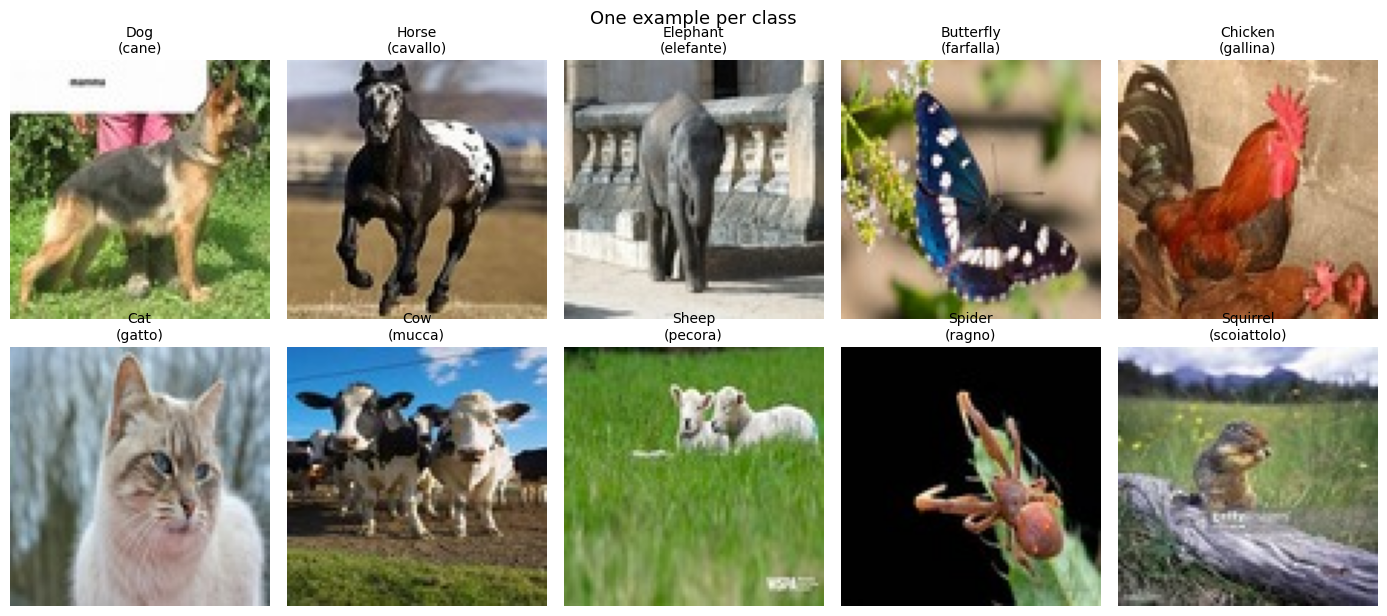

In [5]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_DIR = Path("/content/animals10/normalized-224")

translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"
}

class_to_images = defaultdict(list)
for p in DATA_DIR.glob("*/*.jpg"):
    class_to_images[p.parent.name].append(p)

selected = {cls: random.choice(imgs) for cls, imgs in class_to_images.items() if imgs}

classes = sorted(selected.keys())

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()

for i, cls in enumerate(classes):
    img = Image.open(selected[cls])
    axes[i].imshow(img)
    axes[i].set_title(f"{translate.get(cls, cls).title()}\n({cls})", fontsize=10)
    axes[i].axis('off')

for ax in axes[len(classes):]:
    ax.axis('off')

plt.tight_layout()
plt.suptitle("One example per class", fontsize=13, y=1.02)
plt.show()

#Make dataset split

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#we difine a function to make dataset split
DATA_DIR = "/content/animals10/normalized-224"

#input functions parameters
SEED = 42
IMG_SIZE = (90, 90)
BATCH_SIZE = 32

def make_datasets(batch_size):
    print(f"data-dir: {DATA_DIR}")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=batch_size
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=batch_size
    )
    # Get class names from the dataset created by image_dataset_from_directory
    class_names = train_ds.class_names
    # check avaible resorces of CPU and GPU, distribute in a efficient way
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, class_names



In [7]:
train_ds_check, val_ds_check, _ = make_datasets(batch_size=32)

print(f"Number of training batches (224x224): {tf.data.experimental.cardinality(train_ds_check).numpy()} batches")
print(f"Number of validation batches (224x224): {tf.data.experimental.cardinality(val_ds_check).numpy()} batches")

data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.
Number of training batches (224x224): 655 batches
Number of validation batches (224x224): 164 batches


# Define data augumentation functions

In [8]:
# ashish (temporary)

# ── Data Augmentation (separate method) ───────────────────────────────────────
def build_augmentation():
    """Returns a keras Sequential model for data augmentation."""
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name="data_augmentation")


In [9]:
def data_augumentation(inp):
    data_aug = keras.Sequential([
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        # layers.RandomZoom(0.1, seed=SEED),
    ])
    return data_aug(inp)


    def data_augumentation_test():
     data_aug = keras.Sequential([
         layers.Rescaling(1./255),
         layers.RandomFlip("horizontal", seed=SEED),
         layers.RandomRotation(0.1, seed=SEED),
          layers.RandomZoom(0.1, seed=SEED),
     ])
     return data_aug
    pass

#Build the model

In [10]:
def build_baseline_model():
    inputs = keras.Input(shape=(90, 90, 3))
    # x = data_aug(inputs)
    x = layers.Rescaling(1./255)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
    # x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x) # Apply BatchNormalization to x
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(256, (3,3), padding="same", activation="relu")(x)
    # x = layers.BatchNormalization()
    # x = layers.MaxPooling2D()(x)

    # Block 5
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x) # Apply BatchNormalization to x
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 6
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)

    x = layers.GlobalAveragePooling2D()(x)  # simpler than Flatten, usually better
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="baseline_cnn_v1")


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Tensorboard
import tensorflow as tf
tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir="logs",
    histogram_freq=1
)

# Train the model

In [13]:
def train_one_run(learning_rate, batch_size, max_epochs):
    train_ds, val_ds, class_names = make_datasets(batch_size)

    model = build_baseline_model()
    model.summary()
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        tensorboard
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        callbacks=callbacks
    )
    return model, history, class_names

#Evaluation graphs

In [14]:
# generate the evaluation graph

from matplotlib import pyplot as plt

def evaluation_graph(history):
  # Training curves
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  axes[0].plot(history.history["loss"], label="Train")
  axes[0].plot(history.history["val_loss"], label="Validation")
  axes[0].set_title("Loss")
  axes[0].set_xlabel("Epoch")
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  axes[1].plot(history.history["accuracy"], label="Train")
  axes[1].plot(history.history["val_accuracy"], label="Validation")
  axes[1].set_title("Accuracy")
  axes[1].set_xlabel("Epoch")
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

In [15]:
#  experimentation
d_model, d_history, d_class_names = train_one_run(
    learning_rate=0.001,
    batch_size=16,
    max_epochs=50
)

data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.


Model: "baseline_cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 90, 90, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 90, 90, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 22, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,082 (2.91 MB)

 Trainable params: 762,570 (2.91 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.2334 - loss: 2.1220 - val_accuracy: 0.3104 - val_loss: 2.0731 - learning_rate: 0.0010
Epoch 2/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.4148 - loss: 1.6716 - val_accuracy: 0.4304 - val_loss: 1.7173 - learning_rate: 0.0010
Epoch 3/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.4948 - loss: 1.4482 - val_accuracy: 0.4569 - val_loss: 1.5322 - learning_rate: 0.0010
Epoch 4/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.5493 - loss: 1.3121 - val_accuracy: 0.4840 - val_loss: 1.5776 - learning_rate: 0.0010
Epoch 5/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.5885 - loss: 1.2082 - val_accuracy: 0.6201 - val_loss: 1.1006 - learning_rate: 0.0010
Epoch 6/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.6185 - loss: 1.1288 - val_accuracy: 0.6453 - val_loss: 1.0239 - learning_rate: 0.0010
Epoch 7/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accura

In [18]:
d_model.save("./model_cnn.keras")       # folder with: config.json, pytorch_model.bin, etc.


In [ ]:
evaluation_graph(history=d_history)